In [56]:
import os
from decimal import Decimal, ROUND_HALF_UP

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase

In [2]:
# Create a directory to store the plots in
ora_comparison_plots_dir = "ORA_comparison_plots"

if not os.path.exists(ora_comparison_plots_dir):
    os.makedirs(ora_comparison_plots_dir)

In [3]:
# Load the long format comparison TSV file into a DataFrame
comparison_average_long_df = pd.read_csv(
    "ORA_comparison_average_-log10(Benjamini)_long_format_copy.tsv",
    sep="\t"
)

# Experimentation

In [ ]:
ora_order = [
    "early_low_unrefined",
    "early_low_refined",
    "early_high_unrefined",
    "early_high_refined",
    "late_low_unrefined",
    "late_low_refined",
    "late_high_unrefined",
    "late_high_refined",
]

category_order = [
    "Other",
    "Protein & RNA homeostasis",
    "Cell signaling",
    "DNA replication & repair",
    "Cell cycle & mitosis",
    "Autophagy",
    "Ubiquitin-mediated protein degradation",
    "Cytoskeleton & Rho GTPase signaling",
    "Membrane trafficking & vesicular transport",
    "Immune response & host–pathogen interactions"
]

# Prepare plotting positions
plot_df = comparison_average_long_df.copy()

ora_to_x = {
    ora: x
    for x, ora in enumerate(ora_order)
}
category_to_y = {
    category: y
    for y, category in enumerate(category_order)
}

plot_df["x"] = plot_df["ORA"].map(ora_to_x)
plot_df["y"] = plot_df["category"].map(category_to_y)

# Create the figure
fig, ax = plt.subplots(1, 1, figsize=(10, 7.5))

# Separate zero from non-zero observations via Boolean masks
nonzero = plot_df["genes_fraction"] > 0
zero = ~nonzero

# Perform color normalization
norm = plt.Normalize(
    vmin=plot_df.loc[nonzero, "average_minus_log10(Benjamini)"].min(),
    vmax=plot_df.loc[nonzero, "average_minus_log10(Benjamini)"].max()
)

# Plot non-zero dots
SIZE_SCALE = 120

scatter = ax.scatter(
    x=plot_df.loc[nonzero, "x"],
    y=plot_df.loc[nonzero, "y"],
    s=plot_df.loc[nonzero, "genes_fraction"] * SIZE_SCALE,
    c=plot_df.loc[nonzero, "average_minus_log10(Benjamini)"],
    cmap="viridis",
    norm=norm,
    edgecolors="black",
    linewidth=0.5,
    zorder=3
)

# Plot zero dots
ax.scatter(
    x=plot_df.loc[zero, "x"],
    y=plot_df.loc[zero, "y"],
    s=20,
    facecolors="none",
    edgecolors="black",
    linewidth=0.8,
    zorder=3
)

# Visually pair unrefined and refined intensities via vertical bars
for x in [1.5, 3.5, 5.5]:
    ax.axvline(
        x=x,
        color="black",
        linewidth=1,
        zorder=0
    )

#  Visually separate VACV-related categories from general categories
n_general_categories = 5

ax.axhline(
    y=n_general_categories - 0.5,
    color="black",
    linewidth=1
)

# Add x-axis labels
ax.set_xticks(
    np.arange(len(ora_order))
)

ax.set_xticklabels(
    ["Unrefined", "Refined"] * 4
)

# Add labels for the pairs
pair_centers = [0.5, 2.5, 4.5, 6.5]

pair_labels = [
    "Early low",
    "Early high",
    "Late low",
    "Late high"
]

for pair_center, pair_label in zip(pair_centers, pair_labels):
    # Early/late + low/high label
    ax.text(
        pair_center,
        -0.1,
        pair_label,
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

    # Refinement arrow
    ax.annotate(
        "",
        xy=(pair_center + 0.35, -0.07),
        xytext=(pair_center - 0.35, -0.07),
        xycoords=("data", "axes fraction"),
        textcoords=("data", "axes fraction"),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1,
        )
    )

# Add y-axis ticks and labels
ax.set_yticks(
    np.arange(len(category_order))
)

ax.set_yticklabels(
    category_order
)

# Set y-axis label
ax.set_ylabel(
    "Biological category",
    fontsize=13,
    fontweight="bold"
)

# Add a color bar
cbar = fig.colorbar(
    scatter,
    ax=ax
)

cbar.set_label(
    r"Mean $-\log_{10}$(Benjamini)"
)

# Add a legend for the dot size
# To this end, dummy scatter handles are created
legend_fractions = [0.05, 0.10, 0.20, 0.30, 0.40]

size_legend_handles = [
    ax.scatter(
        [],
        [],
        s=fraction * SIZE_SCALE,
        color="0.6",
        edgecolors="black",
        linewidth=0.8,
        label=f"{fraction:.0%}"
    )
    for fraction in legend_fractions
]

size_legend = ax.legend(
    handles=size_legend_handles,
    title="Fraction of prioritised genes",
    loc="upper left",
    bbox_to_anchor=(1.2, 1.0),
    frameon=False
)

size_legend.get_title().set_fontweight("bold")

# Add the first legend explicitly so it is retained
ax.add_artist(size_legend)

# Add a legend explaining empty circles
# Again, a dummy scatter handle is created
zero_handle = ax.scatter(
    [],
    [],
    s=20,
    facecolors="none",
    edgecolors="black",
    linewidth=0.8,
    label="No significant enrichment"
)

zero_legend = ax.legend(
    handles=[zero_handle],
    title="Enrichment",
    loc="upper left",
    bbox_to_anchor=(1.2, 0.7),
    frameon=False
)

zero_legend.get_title().set_fontweight("bold")

fig.savefig(
    "test_figure.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "test_figure.svg",
    bbox_inches="tight"
)

plt.show()

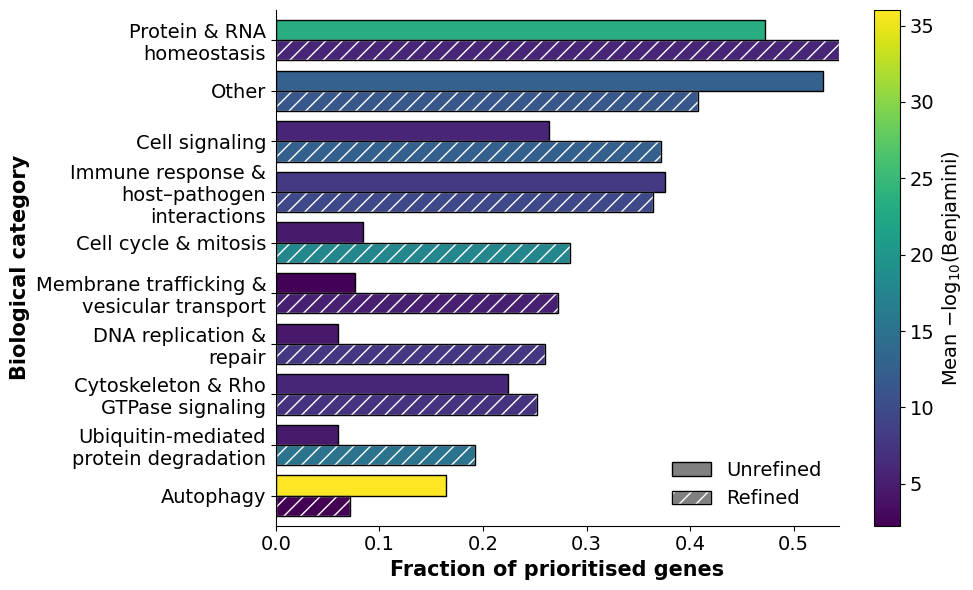

In [ ]:
# Focus on "early low intensities"
early_low_df = comparison_average_long_df[comparison_average_long_df["ORA"].isin(["early_low_unrefined", "early_low_refined"])].copy()

# Sort the y-axis categories in descending order by the fraction of prioritised genes after refinement
# Ascending=True here because barh plots y=0 at the bottom, so largest values will be at the top
sort_order_df = early_low_df[early_low_df["ORA"] == "early_low_refined"].sort_values("genes_fraction", ascending=True)
category_sort_order = sort_order_df["category"].tolist()

# Define y positions
y_positions = np.arange(len(category_sort_order))
bar_height = 0.4

unrefined = early_low_df[early_low_df["ORA"] == "early_low_unrefined"].set_index("category").reindex(category_sort_order)
refined = early_low_df[early_low_df["ORA"] == "early_low_refined"].set_index("category").reindex(category_sort_order)

fig, ax = plt.subplots(figsize=(10, 6))

cmap = plt.get_cmap("viridis")
# Perform color normalization over all early low intensities
norm = plt.Normalize(
    vmin=early_low_df["average_minus_log10(Benjamini)"].min(),
    vmax=early_low_df["average_minus_log10(Benjamini)"].max()
)

# Plot unrefined (top bar for each category, so y + bar_height/2)
ax.barh(
    y_positions + bar_height/2,
    unrefined["genes_fraction"],
    height=bar_height,
    color=cmap(norm(unrefined["average_minus_log10(Benjamini)"])),
    edgecolor="black"
)

# Plot refined (bottom bar for each category, so y - bar_height/2)
# edgecolor="white" makes hatch lines white; transparent overlay restores black border
ax.barh(
    y_positions - bar_height/2,
    refined["genes_fraction"],
    height=bar_height,
    color=cmap(norm(refined["average_minus_log10(Benjamini)"])),
    edgecolor="white",
    hatch="//"
)
# Overlay transparent bars to draw black border on refined bars
ax.barh(
    y_positions - bar_height/2,
    refined["genes_fraction"],
    height=bar_height,
    facecolor="none",
    edgecolor="black"
)

# Remove as much whitespace as possible
ax.margins(y=0.02, x=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_yticks(y_positions)
import textwrap
wrapped_labels = [textwrap.fill(lbl, width=23) for lbl in category_sort_order]
ax.set_yticklabels(wrapped_labels)
ax.set_xlabel("Fraction of prioritised genes", fontweight="bold", fontsize=15)
ax.set_ylabel("Biological category", fontweight="bold", fontsize=15)
ax.tick_params(axis="both", labelsize=14)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"Mean $-\log_{10}$(Benjamini)", fontsize=14)
cbar.ax.tick_params(labelsize=14)

# Legend: both bars shown in gray.
# For the Refined entry, a custom handler overlays two patches on the same area:
#   1. gray fill + white hatch  (gives white diagonal lines)
#   2. transparent fill + black border  (gives black border on top)
class OverlayPatchHandler(HandlerBase):
    """Draws multiple patches overlaid on the same legend key area."""
    def __init__(self, patches, **kwargs):
        self._patches = patches
        super().__init__(**kwargs)
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        artists = []
        for p in self._patches:
            rect = mpatches.Rectangle(
                (-xdescent, -ydescent), width, height,
                facecolor=p.get_facecolor(),
                edgecolor=p.get_edgecolor(),
                hatch=p.get_hatch(),
                linewidth=1.0,
                transform=trans
            )
            artists.append(rect)
        return artists

refined_hatch_patch = mpatches.Patch(facecolor="gray", edgecolor="white", hatch="//")
refined_border_patch = mpatches.Patch(facecolor="none", edgecolor="black")
refined_placeholder = mpatches.Patch(label="Refined")

legend_handles = [
    mpatches.Patch(facecolor="gray", edgecolor="black", label="Unrefined"),
    refined_placeholder
]
ax.legend(
    handles=legend_handles,
    handler_map={refined_placeholder: OverlayPatchHandler([refined_hatch_patch, refined_border_patch])},
    frameon=False,
    fontsize=14
)

plt.tight_layout()
plt.show()

fig.savefig(
    "test_figure.png",
    dpi=300,
    bbox_inches="tight"
)

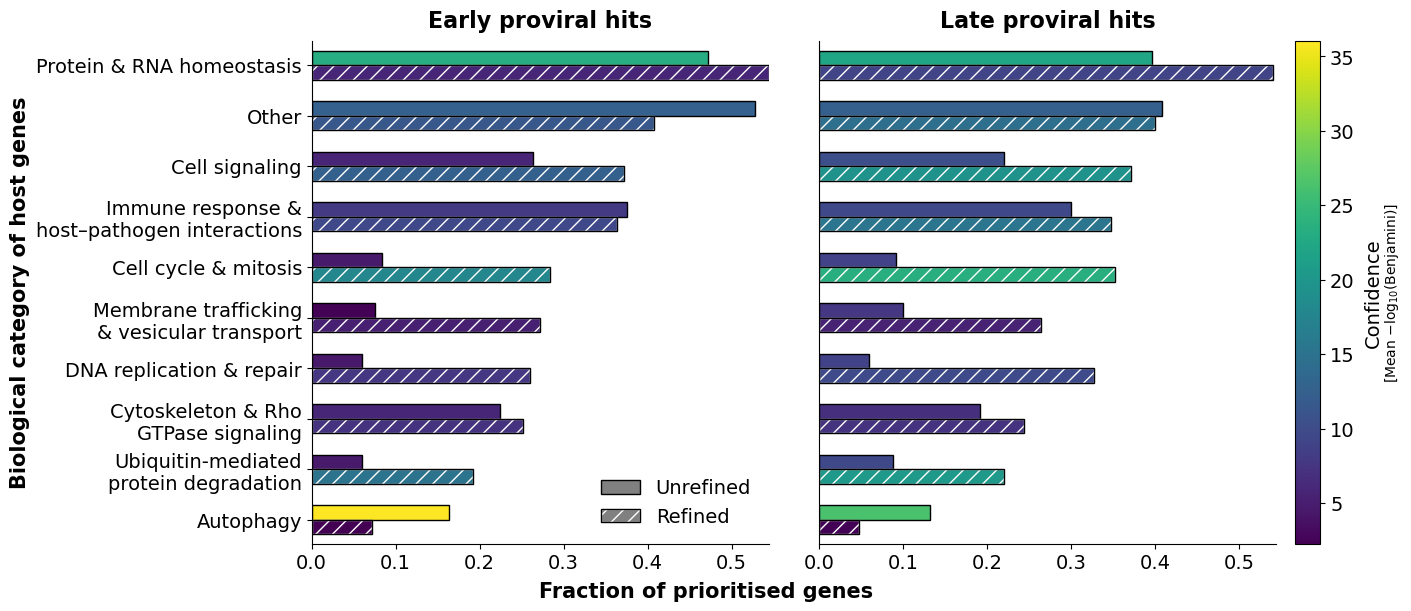

In [33]:
# ============================================================
# Select early-low and late-low data
# ============================================================

early_low_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["early_low_unrefined", "early_low_refined"]
    )
].copy()

late_low_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["late_low_unrefined", "late_low_refined"]
    )
].copy()


# ============================================================
# Sort categories
#
# Keep the category ordering based on the refined early-low
# values, as in the original figure.
# ============================================================

sort_order_df = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ]
    .sort_values("genes_fraction", ascending=True)
)

category_sort_order = sort_order_df["category"].tolist()

group_spacing = 1.4
y_positions = np.arange(len(category_sort_order)) * group_spacing
bar_height = 0.4


# ============================================================
# Reindex data according to common category order
# ============================================================

early_unrefined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_refined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_unrefined = (
    late_low_df[
        late_low_df["ORA"] == "late_low_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_refined = (
    late_low_df[
        late_low_df["ORA"] == "late_low_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)


# ============================================================
# Color map
#
# IMPORTANT:
# The normalization is now performed across BOTH early-low
# and late-low data, so the colors have the same quantitative
# meaning in both panels.
# ============================================================

cmap = plt.get_cmap("viridis")

all_low_df = pd.concat([early_low_df, late_low_df])

norm = plt.Normalize(
    vmin=all_low_df[
        "average_minus_log10(Benjamini)"
    ].min(),
    vmax=all_low_df[
        "average_minus_log10(Benjamini)"
    ].max()
)


# ============================================================
# Create figure and two Axes
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    sharey=True,
    gridspec_kw={"wspace": 0.05},
    constrained_layout=True
)


# ============================================================
# Helper function for plotting one panel
# ============================================================

def plot_comparison(ax, unrefined, refined):
    """
    Plot unrefined and refined horizontal bars on one Axes.
    """

    # --------------------------------------------------------
    # Unrefined
    # --------------------------------------------------------

    ax.barh(
        y_positions + bar_height / 2,
        unrefined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                unrefined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Refined
    #
    # White hatch + white edge gives white hatch lines.
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                refined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="white",
        hatch="//"
    )

    # --------------------------------------------------------
    # Overlay transparent bars to restore black outline
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        facecolor="none",
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.margins(y=0.02, x=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=14
    )


# ============================================================
# Plot the two panels
# ============================================================

plot_comparison(
    ax1,
    early_unrefined,
    early_refined
)

plot_comparison(
    ax2,
    late_unrefined,
    late_refined
)


# ============================================================
# Axis labels and category labels
# ============================================================

# wrapped_labels = [
#     textwrap.fill(lbl, width=23)
#     for lbl in category_sort_order
# ]
def wrap_to_two_lines(text, width=30):
    words = text.split()

    # Nothing to do for short labels
    if len(text) <= width:
        return text

    # Find the split that gives the most balanced two lines
    best_split = None
    best_difference = float("inf")

    for i in range(1, len(words)):
        line1 = " ".join(words[:i])
        line2 = " ".join(words[i:])

        # Skip splits where either line is excessively long
        if len(line1) > width or len(line2) > width:
            continue

        difference = abs(len(line1) - len(line2))

        if difference < best_difference:
            best_difference = difference
            best_split = (line1, line2)

    # If no split satisfies the width constraint, split at
    # the most balanced word boundary anyway.
    if best_split is None:
        differences = []

        for i in range(1, len(words)):
            line1 = " ".join(words[:i])
            line2 = " ".join(words[i:])
            differences.append(
                (abs(len(line1) - len(line2)), line1, line2)
            )

        _, line1, line2 = min(differences)
        best_split = (line1, line2)

    return "\n".join(best_split)


wrapped_labels = [
    wrap_to_two_lines(lbl, width=30)
    for lbl in category_sort_order
]

ax1.set_yticks(y_positions)
ax1.set_yticklabels(wrapped_labels)

ax1.set_ylabel(
    "Biological category of host genes",
    fontweight="bold",
    fontsize=15
)

# ax1.set_xlabel(
#     "Fraction of prioritised genes",
#     fontweight="bold",
#     fontsize=15
# )

# ax2.set_xlabel(
#     "Fraction of prioritised genes",
#     fontweight="bold",
#     fontsize=15
# )

# Hide duplicate y-axis labels/ticks on right panel
ax2.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

# Joint x-axis label
fig.supxlabel(
    "Fraction of prioritised genes",
    fontweight="bold",
    fontsize=15
)


# ============================================================
# Panel titles
# ============================================================

ax1.set_title(
    "Early proviral hits",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax2.set_title(
    "Late proviral hits",
    fontsize=16,
    fontweight="bold",
    pad=10
)


# ============================================================
# Colorbar
#
# One colorbar shared by both Axes.
# ============================================================

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[ax1, ax2],
    pad=0.02
)

# cbar.set_label(
#     r"Mean $-\log_{10}$(Benjamini)",
#     fontsize=14
# )

cbar.ax.tick_params(
    labelsize=14
)

cbar.ax.text(
    3.5, 0.5,
    "Confidence",
    fontsize=14,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="bottom",
    transform=cbar.ax.transAxes,
)

cbar.ax.text(
    3.5, 0.5,
    r"[Mean $-\log_{10}$(Benjamini)]",
    fontsize=10,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="top",
    transform=cbar.ax.transAxes,
)


# ============================================================
# Custom legend handler for refined bars
# ============================================================

class OverlayPatchHandler(HandlerBase):
    """
    Draw multiple patches overlaid in the same legend key.
    """

    def __init__(self, patches, **kwargs):
        self._patches = patches
        super().__init__(**kwargs)

    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans
    ):
        artists = []

        for p in self._patches:
            rect = mpatches.Rectangle(
                (-xdescent, -ydescent),
                width,
                height,
                facecolor=p.get_facecolor(),
                edgecolor=p.get_edgecolor(),
                hatch=p.get_hatch(),
                linewidth=1.0,
                transform=trans
            )
            artists.append(rect)

        return artists


# ============================================================
# Legend
# ============================================================

refined_hatch_patch = mpatches.Patch(
    facecolor="gray",
    edgecolor="white",
    hatch="//"
)

refined_border_patch = mpatches.Patch(
    facecolor="none",
    edgecolor="black"
)

refined_placeholder = mpatches.Patch(
    label="Refined"
)

legend_handles = [
    mpatches.Patch(
        facecolor="gray",
        edgecolor="black",
        label="Unrefined"
    ),
    refined_placeholder
]

ax1.legend(
    handles=legend_handles,
    handler_map={
        refined_placeholder:
            OverlayPatchHandler(
                [
                    refined_hatch_patch,
                    refined_border_patch
                ]
            )
    },
    frameon=False,
    fontsize=14,
    loc="lower right"
)

max_fraction = max(
    early_low_df["genes_fraction"].max(),
    late_low_df["genes_fraction"].max()
)

ax1.set_xlim(0, max_fraction)
ax2.set_xlim(0, max_fraction)

# ============================================================
# Final layout
# ============================================================
plt.show()


# ============================================================
# Save figure
# ============================================================

# fig.savefig(
#     "test_figure_2.png",
#     dpi=300,
#     bbox_inches="tight"
# )


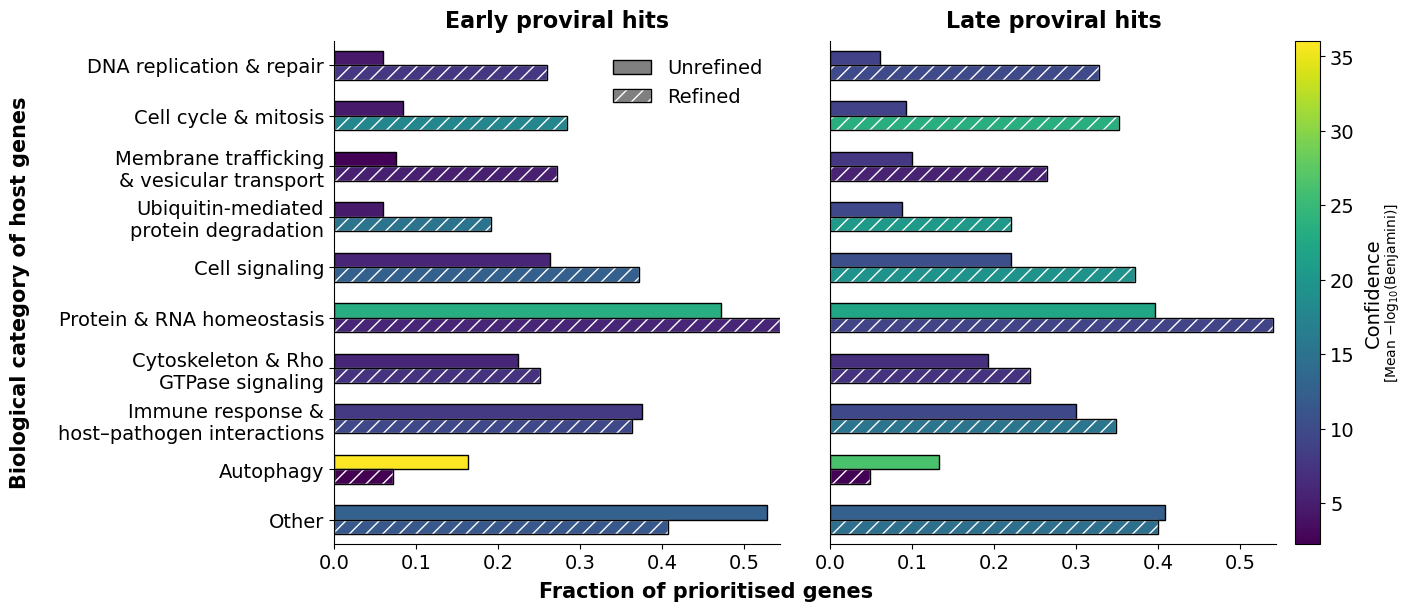

In [5]:
# ============================================================
# Select early-low and late-low data
# ============================================================

early_low_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["early_low_unrefined", "early_low_refined"]
    )
].copy()

late_low_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["late_low_unrefined", "late_low_refined"]
    )
].copy()


# ============================================================
# Sort categories by the difference in early-low intensities
#
# Difference = early_low_refined - early_low_unrefined
#
# Largest positive difference appears at the top.
# ============================================================

early_unrefined_sort = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ][["category", "genes_fraction"]]
    .rename(columns={"genes_fraction": "early_unrefined"})
)

early_refined_sort = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ][["category", "genes_fraction"]]
    .rename(columns={"genes_fraction": "early_refined"})
)

sort_order_df = (
    early_unrefined_sort
    .merge(
        early_refined_sort,
        on="category",
        how="inner"
    )
)

sort_order_df["early_difference"] = (
    sort_order_df["early_refined"]
    - sort_order_df["early_unrefined"]
)

# Sort ascending because barh() places the first
# category at the bottom of the y-axis.
# Consequently, the largest difference appears at the top.
sort_order_df = sort_order_df.sort_values(
    "early_difference",
    ascending=True
)

category_sort_order = sort_order_df["category"].tolist()

group_spacing = 1.4
y_positions = np.arange(len(category_sort_order)) * group_spacing
bar_height = 0.4


# ============================================================
# Reindex data according to common category order
# ============================================================

early_unrefined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_refined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_unrefined = (
    late_low_df[
        late_low_df["ORA"] == "late_low_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_refined = (
    late_low_df[
        late_low_df["ORA"] == "late_low_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)


# ============================================================
# Color map
#
# IMPORTANT:
# The normalization is now performed across BOTH early-low
# and late-low data, so the colors have the same quantitative
# meaning in both panels.
# ============================================================

cmap = plt.get_cmap("viridis")

all_low_df = pd.concat([early_low_df, late_low_df])

norm = plt.Normalize(
    vmin=all_low_df[
        "average_minus_log10(Benjamini)"
    ].min(),
    vmax=all_low_df[
        "average_minus_log10(Benjamini)"
    ].max()
)


# ============================================================
# Create figure and two Axes
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    sharey=True,
    gridspec_kw={"wspace": 0.05},
    constrained_layout=True
)


# ============================================================
# Helper function for plotting one panel
# ============================================================

def plot_comparison(ax, unrefined, refined):
    """
    Plot unrefined and refined horizontal bars on one Axes.
    """

    # --------------------------------------------------------
    # Unrefined
    # --------------------------------------------------------

    ax.barh(
        y_positions + bar_height / 2,
        unrefined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                unrefined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Refined
    #
    # White hatch + white edge gives white hatch lines.
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                refined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="white",
        hatch="//"
    )

    # --------------------------------------------------------
    # Overlay transparent bars to restore black outline
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        facecolor="none",
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.margins(y=0.02, x=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=14
    )


# ============================================================
# Plot the two panels
# ============================================================

plot_comparison(
    ax1,
    early_unrefined,
    early_refined
)

plot_comparison(
    ax2,
    late_unrefined,
    late_refined
)


# ============================================================
# Axis labels and category labels
# ============================================================

# wrapped_labels = [
#     textwrap.fill(lbl, width=23)
#     for lbl in category_sort_order
# ]
def wrap_to_two_lines(text, width=30):
    words = text.split()

    # Nothing to do for short labels
    if len(text) <= width:
        return text

    # Find the split that gives the most balanced two lines
    best_split = None
    best_difference = float("inf")

    for i in range(1, len(words)):
        line1 = " ".join(words[:i])
        line2 = " ".join(words[i:])

        # Skip splits where either line is excessively long
        if len(line1) > width or len(line2) > width:
            continue

        difference = abs(len(line1) - len(line2))

        if difference < best_difference:
            best_difference = difference
            best_split = (line1, line2)

    # If no split satisfies the width constraint, split at
    # the most balanced word boundary anyway.
    if best_split is None:
        differences = []

        for i in range(1, len(words)):
            line1 = " ".join(words[:i])
            line2 = " ".join(words[i:])
            differences.append(
                (abs(len(line1) - len(line2)), line1, line2)
            )

        _, line1, line2 = min(differences)
        best_split = (line1, line2)

    return "\n".join(best_split)


wrapped_labels = [
    wrap_to_two_lines(lbl, width=30)
    for lbl in category_sort_order
]

ax1.set_yticks(y_positions)
ax1.set_yticklabels(wrapped_labels)

ax1.set_ylabel(
    "Biological category of host genes",
    fontweight="bold",
    fontsize=15,
    labelpad=20
)

# ax1.set_xlabel(
#     "Fraction of prioritised genes",
#     fontweight="bold",
#     fontsize=15
# )

# ax2.set_xlabel(
#     "Fraction of prioritised genes",
#     fontweight="bold",
#     fontsize=15
# )

# Hide duplicate y-axis labels/ticks on right panel
ax2.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

# Joint x-axis label
fig.supxlabel(
    "Fraction of prioritised genes",
    fontweight="bold",
    fontsize=15
)


# ============================================================
# Panel titles
# ============================================================

ax1.set_title(
    "Early proviral hits",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax2.set_title(
    "Late proviral hits",
    fontsize=16,
    fontweight="bold",
    pad=10
)


# ============================================================
# Colorbar
#
# One colorbar shared by both Axes.
# ============================================================

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[ax1, ax2],
    pad=0.02
)

# cbar.set_label(
#     r"Mean $-\log_{10}$(Benjamini)",
#     fontsize=14
# )

cbar.ax.tick_params(
    labelsize=14
)

cbar.ax.text(
    3.5, 0.5,
    "Confidence",
    fontsize=14,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="bottom",
    transform=cbar.ax.transAxes,
)

cbar.ax.text(
    3.5, 0.5,
    r"[Mean $-\log_{10}$(Benjamini)]",
    fontsize=10,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="top",
    transform=cbar.ax.transAxes,
)


# ============================================================
# Custom legend handler for refined bars
# ============================================================

class OverlayPatchHandler(HandlerBase):
    """
    Draw multiple patches overlaid in the same legend key.
    """

    def __init__(self, patches, **kwargs):
        self._patches = patches
        super().__init__(**kwargs)

    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans
    ):
        artists = []

        for p in self._patches:
            rect = mpatches.Rectangle(
                (-xdescent, -ydescent),
                width,
                height,
                facecolor=p.get_facecolor(),
                edgecolor=p.get_edgecolor(),
                hatch=p.get_hatch(),
                linewidth=1.0,
                transform=trans
            )
            artists.append(rect)

        return artists


# ============================================================
# Legend
# ============================================================

refined_hatch_patch = mpatches.Patch(
    facecolor="gray",
    edgecolor="white",
    hatch="//"
)

refined_border_patch = mpatches.Patch(
    facecolor="none",
    edgecolor="black"
)

refined_placeholder = mpatches.Patch(
    label="Refined"
)

legend_handles = [
    mpatches.Patch(
        facecolor="gray",
        edgecolor="black",
        label="Unrefined"
    ),
    refined_placeholder
]

ax1.legend(
    handles=legend_handles,
    handler_map={
        refined_placeholder:
            OverlayPatchHandler(
                [
                    refined_hatch_patch,
                    refined_border_patch
                ]
            )
    },
    frameon=False,
    fontsize=14,
    loc="upper right"
)

max_fraction = max(
    early_low_df["genes_fraction"].max(),
    late_low_df["genes_fraction"].max()
)

ax1.set_xlim(0, max_fraction)
ax2.set_xlim(0, max_fraction)


# ============================================================
# Final layout
# ============================================================
plt.show()


# ============================================================
# Save figure
# ============================================================

# fig.savefig(
#     "test_figure_2.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Generation of Figures for Manuscript

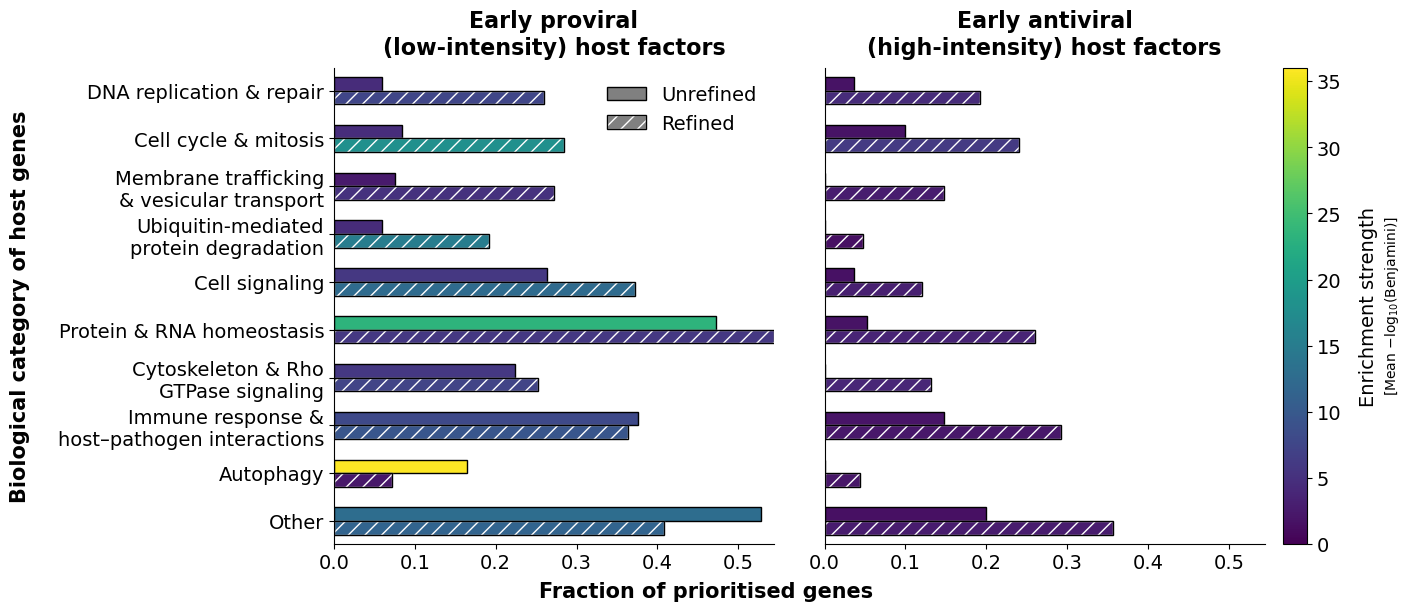

In [15]:
# Generate the figure for the main manuscript displaying early low
# (proviral) and early high (antiviral) intensities
# Only these two intensity regimes are shown as the trends are similar
# for late intensities

# ============================================================
# Select early-low and early-high data
#
# Early-low  = low-intensity proviral host factors
# Early-high = high-intensity antiviral host factors
# ============================================================

early_low_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["early_low_unrefined", "early_low_refined"]
    )
].copy()

early_high_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["early_high_unrefined", "early_high_refined"]
    )
].copy()


# ============================================================
# Sort categories by the difference in early-low intensities
#
# Difference = early_low_refined - early_low_unrefined
#
# Largest positive difference appears at the top.
# ============================================================

early_unrefined_sort = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ][["category", "genes_fraction"]]
    .rename(columns={"genes_fraction": "early_unrefined"})
)

early_refined_sort = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ][["category", "genes_fraction"]]
    .rename(columns={"genes_fraction": "early_refined"})
)

sort_order_df = (
    early_unrefined_sort
    .merge(
        early_refined_sort,
        on="category",
        how="inner"
    )
)

sort_order_df["early_difference"] = (
    sort_order_df["early_refined"]
    - sort_order_df["early_unrefined"]
)

# Sort ascending because barh() places the first
# category at the bottom of the y-axis.
# Consequently, the largest difference appears at the top.
sort_order_df = sort_order_df.sort_values(
    "early_difference",
    ascending=True
)

category_sort_order = sort_order_df["category"].tolist()

group_spacing = 1.4
y_positions = np.arange(len(category_sort_order)) * group_spacing
bar_height = 0.4


# ============================================================
# Reindex data according to common category order
# ============================================================

early_unrefined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_refined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_high_unrefined = (
    early_high_df[
        early_high_df["ORA"] == "early_high_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_high_refined = (
    early_high_df[
        early_high_df["ORA"] == "early_high_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)


# ============================================================
# Color map
#
# IMPORTANT:
# The normalization is performed across BOTH early-low
# and early-high data, so the colors have the same
# quantitative meaning in both panels.
# ============================================================

cmap = plt.get_cmap("viridis")

all_early_df = pd.concat(
    [early_low_df, early_high_df]
)

norm = plt.Normalize(
    vmin=all_early_df[
        "average_minus_log10(Benjamini)"
    ].min(),
    vmax=all_early_df[
        "average_minus_log10(Benjamini)"
    ].max()
)


# ============================================================
# Create figure and two Axes
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    sharey=True,
    gridspec_kw={"wspace": 0.05},
    constrained_layout=True
)


# ============================================================
# Helper function for plotting one panel
# ============================================================

def plot_comparison(ax, unrefined, refined):
    """
    Plot unrefined and refined horizontal bars on one Axes.
    """

    # --------------------------------------------------------
    # Unrefined
    # --------------------------------------------------------

    ax.barh(
        y_positions + bar_height / 2,
        unrefined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                unrefined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Refined
    #
    # White hatch + white edge gives white hatch lines.
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                refined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="white",
        hatch="//"
    )

    # --------------------------------------------------------
    # Overlay transparent bars to restore black outline
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        facecolor="none",
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.margins(y=0.02, x=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=14
    )


# ============================================================
# Plot the two panels
# ============================================================

# Panel 1: Low-intensity proviral host factors
plot_comparison(
    ax1,
    early_unrefined,
    early_refined
)

# Panel 2: High-intensity antiviral host factors
plot_comparison(
    ax2,
    early_high_unrefined,
    early_high_refined
)


# ============================================================
# Axis labels and category labels
# ============================================================

def wrap_to_two_lines(text, width=30):
    words = text.split()

    # Nothing to do for short labels
    if len(text) <= width:
        return text

    # Find the split that gives the most balanced two lines
    best_split = None
    best_difference = float("inf")

    for i in range(1, len(words)):
        line1 = " ".join(words[:i])
        line2 = " ".join(words[i:])

        # Skip splits where either line is excessively long
        if len(line1) > width or len(line2) > width:
            continue

        difference = abs(len(line1) - len(line2))

        if difference < best_difference:
            best_difference = difference
            best_split = (line1, line2)

    # If no split satisfies the width constraint, split at
    # the most balanced word boundary anyway.
    if best_split is None:
        differences = []

        for i in range(1, len(words)):
            line1 = " ".join(words[:i])
            line2 = " ".join(words[i:])
            differences.append(
                (abs(len(line1) - len(line2)), line1, line2)
            )

        _, line1, line2 = min(differences)
        best_split = (line1, line2)

    return "\n".join(best_split)


wrapped_labels = [
    wrap_to_two_lines(lbl, width=30)
    for lbl in category_sort_order
]

ax1.set_yticks(y_positions)
ax1.set_yticklabels(wrapped_labels)

ax1.set_ylabel(
    "Biological category of host genes",
    fontweight="bold",
    fontsize=15,
    labelpad=20
)


# ============================================================
# Hide duplicate y-axis labels/ticks on right panel
# ============================================================

ax2.tick_params(
    axis="y",
    left=False,
    labelleft=False
)


# ============================================================
# Joint x-axis label
# ============================================================

fig.supxlabel(
    "Fraction of prioritised genes",
    fontweight="bold",
    fontsize=15
)


# ============================================================
# Panel titles
# ============================================================

ax1.set_title(
    "Early proviral\n(low-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax2.set_title(
    "Early antiviral\n(high-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)


# ============================================================
# Colorbar
#
# One colorbar shared by both Axes.
# ============================================================

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[ax1, ax2],
    pad=0.02
)

cbar.ax.tick_params(
    labelsize=14
)

cbar.ax.text(
    4, 0.5,
    "Enrichment strength",
    fontsize=14,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="bottom",
    transform=cbar.ax.transAxes,
)

cbar.ax.text(
    4.2, 0.5,
    r"[Mean $-\log_{10}$(Benjamini)]",
    fontsize=10,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="top",
    transform=cbar.ax.transAxes,
)


# ============================================================
# Custom legend handler for refined bars
# ============================================================

class OverlayPatchHandler(HandlerBase):
    """
    Draw multiple patches overlaid in the same legend key.
    """

    def __init__(self, patches, **kwargs):
        self._patches = patches
        super().__init__(**kwargs)

    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans
    ):
        artists = []

        for p in self._patches:
            rect = mpatches.Rectangle(
                (-xdescent, -ydescent),
                width,
                height,
                facecolor=p.get_facecolor(),
                edgecolor=p.get_edgecolor(),
                hatch=p.get_hatch(),
                linewidth=1.0,
                transform=trans
            )
            artists.append(rect)

        return artists


# ============================================================
# Legend
# ============================================================

refined_hatch_patch = mpatches.Patch(
    facecolor="gray",
    edgecolor="white",
    hatch="//"
)

refined_border_patch = mpatches.Patch(
    facecolor="none",
    edgecolor="black"
)

refined_placeholder = mpatches.Patch(
    label="Refined"
)

legend_handles = [
    mpatches.Patch(
        facecolor="gray",
        edgecolor="black",
        label="Unrefined"
    ),
    refined_placeholder
]

ax1.legend(
    handles=legend_handles,
    handler_map={
        refined_placeholder:
            OverlayPatchHandler(
                [
                    refined_hatch_patch,
                    refined_border_patch
                ]
            )
    },
    frameon=False,
    fontsize=14,
    loc="upper right"
)


# ============================================================
# X-axis limits
# ============================================================

max_fraction = max(
    early_low_df["genes_fraction"].max(),
    early_high_df["genes_fraction"].max()
)

ax1.set_xlim(0, max_fraction)
ax2.set_xlim(0, max_fraction)


# ============================================================
# Final layout
# ============================================================

plt.show()


# ============================================================
# Save figure
# ============================================================

fig.savefig(
    os.path.join(
        ora_comparison_plots_dir,
        "comparison_early_low_and_early_high.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(
        ora_comparison_plots_dir,
        "comparison_early_low_and_early_high.svg"
    ),
    bbox_inches="tight"
)

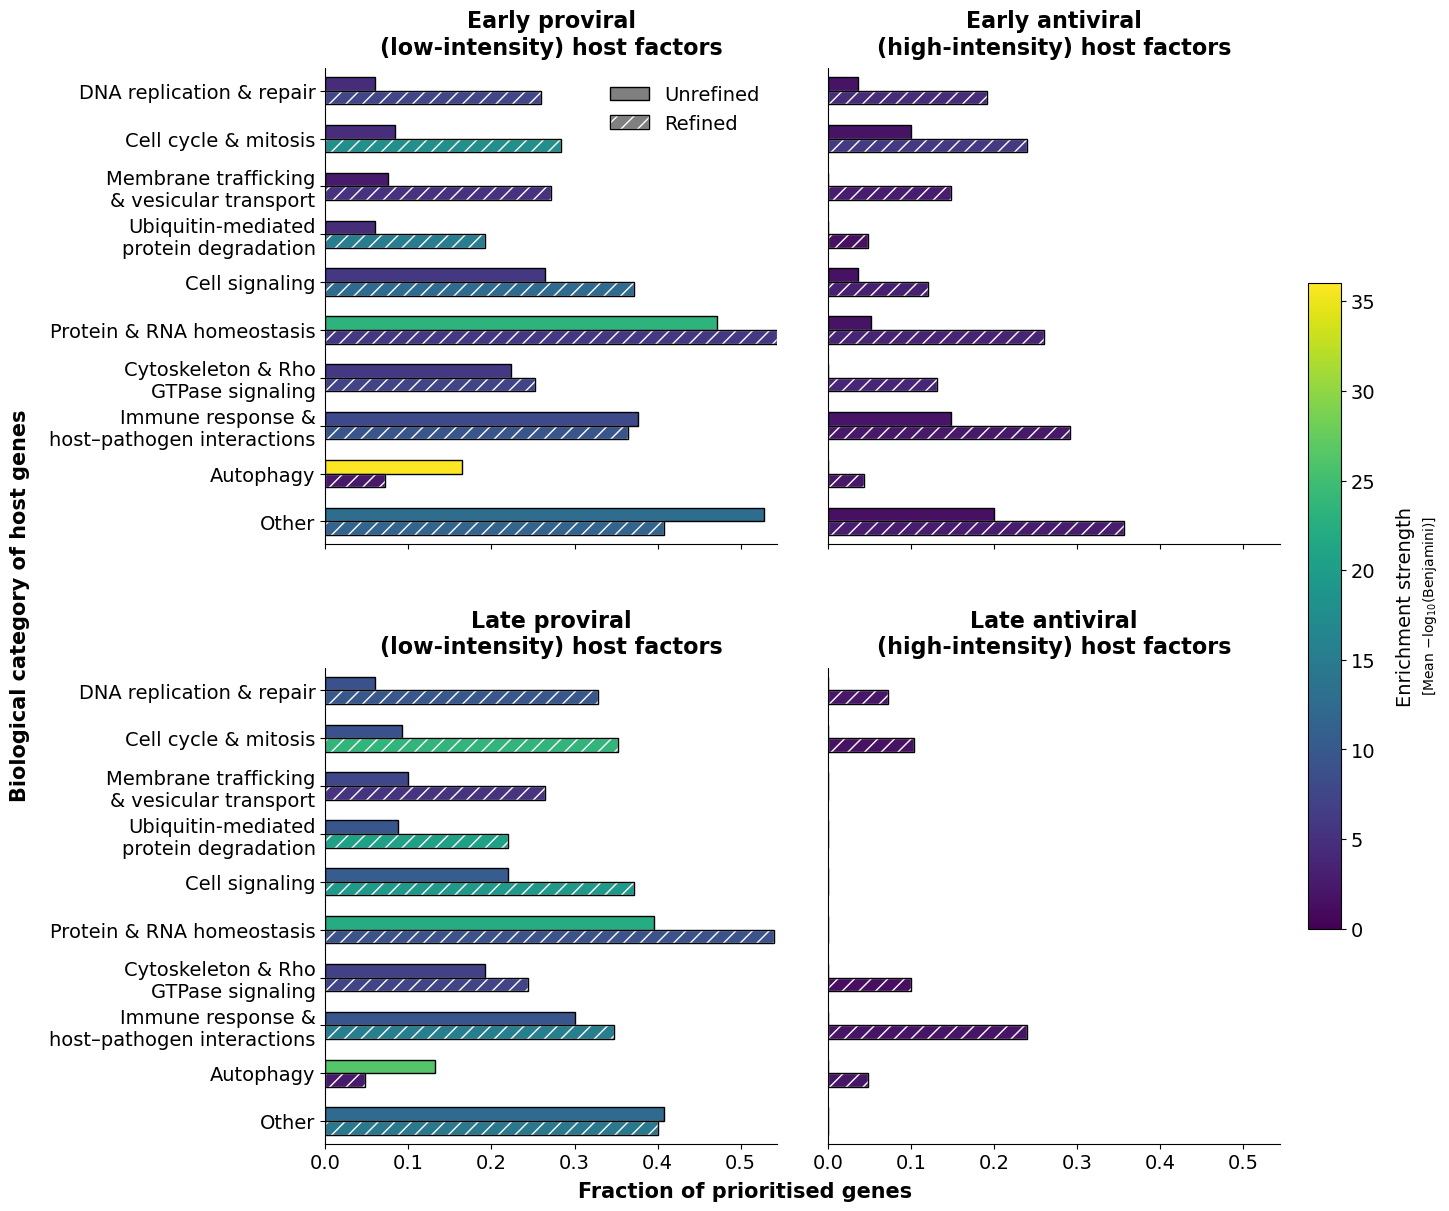

In [54]:
# Generate the figure for the Supplementary Information displaying all
# four intensity regimes

# Generate the figure for the main manuscript displaying
# early and late low- and high-intensity host factors.
#
# Layout:
#   Top-left:     Early proviral (low-intensity)
#   Top-right:    Early antiviral (high-intensity)
#   Bottom-left:  Late proviral (low-intensity)
#   Bottom-right: Late antiviral (high-intensity)
#
# All four panels use:
#   - the same category ordering
#   - the same x-axis scale
#   - the same color normalization
#
# ============================================================
# Select early- and late-intensity data
# ============================================================

early_low_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["early_low_unrefined", "early_low_refined"]
    )
].copy()

early_high_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["early_high_unrefined", "early_high_refined"]
    )
].copy()

late_low_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["late_low_unrefined", "late_low_refined"]
    )
].copy()

late_high_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["late_high_unrefined", "late_high_refined"]
    )
].copy()


# ============================================================
# Sort categories by the difference in early-low intensities
#
# Difference = early_low_refined - early_low_unrefined
#
# Largest positive difference appears at the top.
# ============================================================

early_unrefined_sort = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ][["category", "genes_fraction"]]
    .rename(columns={"genes_fraction": "early_unrefined"})
)

early_refined_sort = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ][["category", "genes_fraction"]]
    .rename(columns={"genes_fraction": "early_refined"})
)

sort_order_df = (
    early_unrefined_sort
    .merge(
        early_refined_sort,
        on="category",
        how="inner"
    )
)

sort_order_df["early_difference"] = (
    sort_order_df["early_refined"]
    - sort_order_df["early_unrefined"]
)

# Sort ascending because barh() places the first
# category at the bottom of the y-axis.
# Consequently, the largest difference appears at the top.
sort_order_df = sort_order_df.sort_values(
    "early_difference",
    ascending=True
)

category_sort_order = sort_order_df["category"].tolist()

group_spacing = 1.4
y_positions = np.arange(len(category_sort_order)) * group_spacing
bar_height = 0.4


# ============================================================
# Reindex data according to common category order
# ============================================================

early_unrefined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_refined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_high_unrefined = (
    early_high_df[
        early_high_df["ORA"] == "early_high_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_high_refined = (
    early_high_df[
        early_high_df["ORA"] == "early_high_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_unrefined = (
    late_low_df[
        late_low_df["ORA"] == "late_low_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_refined = (
    late_low_df[
        late_low_df["ORA"] == "late_low_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_high_unrefined = (
    late_high_df[
        late_high_df["ORA"] == "late_high_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_high_refined = (
    late_high_df[
        late_high_df["ORA"] == "late_high_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)


# ============================================================
# Color map
#
# IMPORTANT:
# Normalization is performed across ALL FOUR panels so that
# the colors have the same quantitative meaning throughout
# the entire figure.
# ============================================================

cmap = plt.get_cmap("viridis")

all_intensity_df = pd.concat(
    [
        early_low_df,
        early_high_df,
        late_low_df,
        late_high_df
    ]
)

norm = plt.Normalize(
    vmin=all_intensity_df[
        "average_minus_log10(Benjamini)"
    ].min(),
    vmax=all_intensity_df[
        "average_minus_log10(Benjamini)"
    ].max()
)


# ============================================================
# Create figure and four Axes
#
# 2 x 2 square arrangement:
#
#   ax1 | ax2
#   ----+----
#   ax3 | ax4
#
# Early plots are in the upper row.
# Late plots are in the lower row.
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12),
    sharex=True,
    sharey=True,
    gridspec_kw={
        "wspace": 0.05,
        "hspace": 0.10
    },
    constrained_layout=True
)

ax1, ax2 = axes[0]
ax3, ax4 = axes[1]


# ============================================================
# Helper function for plotting one panel
# ============================================================

def plot_comparison(ax, unrefined, refined):
    """
    Plot unrefined and refined horizontal bars on one Axes.
    """

    # --------------------------------------------------------
    # Unrefined
    # --------------------------------------------------------

    ax.barh(
        y_positions + bar_height / 2,
        unrefined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                unrefined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Refined
    #
    # White hatch + white edge gives white hatch lines.
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                refined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="white",
        hatch="//"
    )

    # --------------------------------------------------------
    # Overlay transparent bars to restore black outline
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        facecolor="none",
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.margins(y=0.02, x=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=14
    )


# ============================================================
# Plot the four panels
# ============================================================

# ------------------------------------------------------------
# Top row: Early
# ------------------------------------------------------------

# Panel 1: Early low-intensity proviral host factors
plot_comparison(
    ax1,
    early_unrefined,
    early_refined
)

# Panel 2: Early high-intensity antiviral host factors
plot_comparison(
    ax2,
    early_high_unrefined,
    early_high_refined
)


# ------------------------------------------------------------
# Bottom row: Late
# ------------------------------------------------------------

# Panel 3: Late low-intensity proviral host factors
plot_comparison(
    ax3,
    late_unrefined,
    late_refined
)

# Panel 4: Late high-intensity antiviral host factors
plot_comparison(
    ax4,
    late_high_unrefined,
    late_high_refined
)


# ============================================================
# Axis labels and category labels
# ============================================================

def wrap_to_two_lines(text, width=30):
    words = text.split()

    # Nothing to do for short labels
    if len(text) <= width:
        return text

    # Find the split that gives the most balanced two lines
    best_split = None
    best_difference = float("inf")

    for i in range(1, len(words)):
        line1 = " ".join(words[:i])
        line2 = " ".join(words[i:])

        # Skip splits where either line is excessively long
        if len(line1) > width or len(line2) > width:
            continue

        difference = abs(len(line1) - len(line2))

        if difference < best_difference:
            best_difference = difference
            best_split = (line1, line2)

    # If no split satisfies the width constraint, split at
    # the most balanced word boundary anyway.
    if best_split is None:
        differences = []

        for i in range(1, len(words)):
            line1 = " ".join(words[:i])
            line2 = " ".join(words[i:])
            differences.append(
                (abs(len(line1) - len(line2)), line1, line2)
            )

        _, line1, line2 = min(differences)
        best_split = (line1, line2)

    return "\n".join(best_split)


wrapped_labels = [
    wrap_to_two_lines(lbl, width=30)
    for lbl in category_sort_order
]


# ============================================================
# Y-axis labels
# ============================================================

# Left column gets the category labels
ax1.set_yticks(y_positions)
ax1.set_yticklabels(wrapped_labels)

ax3.set_yticks(y_positions)
ax3.set_yticklabels(wrapped_labels)

fig.supylabel(
    "Biological category of host genes",
    fontweight="bold",
    fontsize=15,
    x=-0.025
)


# ============================================================
# Hide duplicate y-axis labels/ticks on right panels
# ============================================================

for ax in [ax2, ax4]:
    ax.tick_params(
        axis="y",
        left=False,
        labelleft=False
    )


# ============================================================
# Joint x-axis label
# ============================================================

fig.supxlabel(
    "Fraction of prioritised genes",
    fontweight="bold",
    fontsize=15
)


# ============================================================
# Panel titles
# ============================================================

ax1.set_title(
    "Early proviral\n(low-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax2.set_title(
    "Early antiviral\n(high-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax3.set_title(
    "Late proviral\n(low-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax4.set_title(
    "Late antiviral\n(high-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)


# ============================================================
# Colorbar
#
# Let constrained_layout manage the colorbar position.
# shrink controls its height; pad controls its distance
# from the plot axes.
# ============================================================

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    shrink=0.60,
    pad=0.03
)

cbar.ax.tick_params(
    labelsize=14
)

cbar.ax.text(
    3.3, 0.5,
    "Enrichment strength",
    fontsize=14,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="bottom",
    transform=cbar.ax.transAxes,
)

cbar.ax.text(
    3.5, 0.5,
    r"[Mean $-\log_{10}$(Benjamini)]",
    fontsize=10,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="top",
    transform=cbar.ax.transAxes,
)


# ============================================================
# Custom legend handler for refined bars
# ============================================================

class OverlayPatchHandler(HandlerBase):
    """
    Draw multiple patches overlaid in the same legend key.
    """

    def __init__(self, patches, **kwargs):
        self._patches = patches
        super().__init__(**kwargs)

    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans
    ):
        artists = []

        for p in self._patches:
            rect = mpatches.Rectangle(
                (-xdescent, -ydescent),
                width,
                height,
                facecolor=p.get_facecolor(),
                edgecolor=p.get_edgecolor(),
                hatch=p.get_hatch(),
                linewidth=1.0,
                transform=trans
            )
            artists.append(rect)

        return artists


# ============================================================
# Legend
#
# Place the legend only once, in the upper-left panel.
# ============================================================

refined_hatch_patch = mpatches.Patch(
    facecolor="gray",
    edgecolor="white",
    hatch="//"
)

refined_border_patch = mpatches.Patch(
    facecolor="none",
    edgecolor="black"
)

refined_placeholder = mpatches.Patch(
    label="Refined"
)

legend_handles = [
    mpatches.Patch(
        facecolor="gray",
        edgecolor="black",
        label="Unrefined"
    ),
    refined_placeholder
]

ax1.legend(
    handles=legend_handles,
    handler_map={
        refined_placeholder:
            OverlayPatchHandler(
                [
                    refined_hatch_patch,
                    refined_border_patch
                ]
            )
    },
    frameon=False,
    fontsize=14,
    loc="upper right"
)


# ============================================================
# X-axis limits
#
# Use one common limit across all four panels.
# ============================================================

max_fraction = max(
    early_low_df["genes_fraction"].max(),
    early_high_df["genes_fraction"].max(),
    late_low_df["genes_fraction"].max(),
    late_high_df["genes_fraction"].max()
)

for ax in axes.ravel():
    ax.set_xlim(0, max_fraction)


# ============================================================
# Final layout
# ============================================================

plt.show()


# ============================================================
# Save figure
# ============================================================

fig.savefig(
    os.path.join(
        ora_comparison_plots_dir,
        "comparison_early_and_late_low_and_high.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(
        ora_comparison_plots_dir,
        "comparison_early_and_late_low_and_high.svg"
    ),
    bbox_inches="tight"
)

# Formatting TSV File for Display in Supplementary Information

In [57]:
# Create a copy for manuscript formatting
table_df = comparison_average_long_df.copy()

# ============================================================
# Format average_minus_log10(Benjamini)
#
# Round to two decimal places using HALF-UP rounding.
# Converting to string ensures that trailing zeros are retained.
# ============================================================

table_df["average_minus_log10(Benjamini)"] = (
    table_df["average_minus_log10(Benjamini)"]
    .apply(
        lambda x: format(
            Decimal(str(x)).quantize(
                Decimal("0.001"),
                rounding=ROUND_HALF_UP
            ),
            ".3f"
        )
    )
)

# Display the formatted table as TSV
print(
    table_df.to_csv(
        sep="\t",
        index=False
    )
)

category	average_minus_log10(Benjamini)	n_terms	genes_fraction	ORA
Cell cycle & mitosis	4.629	36	0.084	early_low_unrefined
DNA replication & repair	4.463	12	0.06	early_low_unrefined
Cytoskeleton & Rho GTPase signaling	5.840	6	0.224	early_low_unrefined
Membrane trafficking & vesicular transport	2.415	6	0.076	early_low_unrefined
Immune response & host–pathogen interactions	7.966	51	0.376	early_low_unrefined
Protein & RNA homeostasis	23.244	45	0.472	early_low_unrefined
Ubiquitin-mediated protein degradation	4.501	9	0.06	early_low_unrefined
Autophagy	36.020	1	0.164	early_low_unrefined
Cell signaling	5.783	59	0.264	early_low_unrefined
Other	12.664	21	0.528	early_low_unrefined
Cell cycle & mitosis	17.923	52	0.284	early_low_refined
DNA replication & repair	7.571	55	0.26	early_low_refined
Cytoskeleton & Rho GTPase signaling	7.228	11	0.252	early_low_refined
Membrane trafficking & vesicular transport	5.168	17	0.272	early_low_refined
Immune response & host–pathogen interactions	9.622	74	0.364	ear